# 07 - Backtesting V3: motor avanzado y comparación progresiva

Este notebook implementa la tercera versión del backtesting de la estrategia DOGE/USDT.

La finalidad de V3 es avanzar desde las dos versiones anteriores hacia una simulación más rica y cercana a condiciones operativas reales, manteniendo una separación metodológica clara:

- V1 representa el baseline operativo inicial, long-only, agresivo y basado en probabilidades raw
- V2 representa una mejora operativa prudente, long-only, con probabilidades suavizadas, TP/SL por ATR, exposición limitada y fees
- V3 introduce una capa más avanzada de decisión y evaluación, incorporando filtros de régimen, posiciones short simuladas, slippage, threshold tuning y gestión dinámica de posición

El objetivo no es presentar un sistema listo para operar ni una recomendación financiera. La finalidad es evaluar si una arquitectura de backtesting más realista permite entender mejor las limitaciones del modelo supervisado y de la lógica de trading.

Este notebook mantiene el mismo modelo ML que las versiones anteriores. Por tanto, cualquier mejora observada debe interpretarse como una mejora del motor operativo, no como una mejora predictiva del modelo.

In [1]:
# ============================================================
# Imports and configuration
# En esta celda se importan las librerías necesarias y se definen los parámetros generales del Backtesting V3.
# V3 mantiene el mismo modelo supervisado que V1 y V2, pero añade filtros de régimen, shorts simulados, slippage, threshold tuning y position sizing dinámico.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import joblib
from IPython.display import display

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")
MODEL_PATH = Path("../models/xgboost.joblib")
RESULTS_DIR = Path("../results")

# ------------------------------------------------------------
# General parameters
# ------------------------------------------------------------

INITIAL_BALANCE = 1000
TEST_FRACTION = 0.20
SAVE_RESULTS = False

# ------------------------------------------------------------
# Trading costs
# ------------------------------------------------------------

FEE_RATE = 0.001          # Comisión por operación: 0.1%
SLIPPAGE_RATE = 0.0005   # Slippage simulado: 0.05%

# ------------------------------------------------------------
# V1 reference parameters
# ------------------------------------------------------------

V1_BUY_THRESHOLD = 0.55
V1_SELL_THRESHOLD = 0.45
V1_TP_PCT = 0.03
V1_SL_PCT = 0.02
V1_COOLDOWN_BARS = 12

# ------------------------------------------------------------
# V2 reference parameters
# ------------------------------------------------------------

SMOOTH_WINDOW = 3
V2_BUY_THRESHOLD = 0.55
V2_SELL_THRESHOLD = 0.45
V2_MAX_POSITION_SIZE = 0.50
V2_ATR_MULT_TP = 3.0
V2_ATR_MULT_SL = 2.0
V2_COOLDOWN_BARS = 12

# ------------------------------------------------------------
# V3 strategy parameters
# ------------------------------------------------------------

V3_LONG_THRESHOLD = 0.54
V3_SHORT_THRESHOLD = 0.48
V3_MIN_POSITION_SIZE = 0.05
V3_BASE_POSITION_SIZE = 0.25
V3_MAX_POSITION_SIZE = 0.50
V3_ATR_MULT_TP = 3.0
V3_ATR_MULT_SL = 2.0
V3_COOLDOWN_BARS = 12

# ------------------------------------------------------------
# Regime filter parameters
# ------------------------------------------------------------

MIN_ATR_RATIO = 0.002
MAX_ATR_RATIO = 0.060
TREND_CONFIRMATION_WINDOW = 6


In [2]:
# ============================================================
# Load model and dataset
# Se cargan el dataset enriquecido y el modelo supervisado entrenado en el notebook de baseline.
# El notebook reutiliza las mismas features para que la comparación V1-V2-V3 mida cambios de ejecución, no cambios de entrenamiento.
# ============================================================

bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
feature_cols = bundle["feature_cols"]
target = bundle.get("target", "up_1")

df = pd.read_csv(DATA_PATH)

if "open_time" in df.columns:
    df["open_time"] = pd.to_datetime(df["open_time"])

print("Modelo cargado correctamente")
print("Target del modelo:", target)
print("Número de features:", len(feature_cols))
print("Tipo de modelo:", type(model))
print("Shape del dataset:", df.shape)

df.head()


Modelo cargado correctamente
Target del modelo: up_1
Número de features: 40
Tipo de modelo: <class 'xgboost.sklearn.XGBClassifier'>
Shape del dataset: (723080, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-06 11:55:00,0.003630,0.003644,0.003630,0.003635,472036.0,2019-07-06 11:59:59.999,1718.044681,24,405943.0,...,0.081048,0.00355,0.004600,0.023411,0.265440,0,0,0.0,0.0,0.0
1,2019-07-06 12:00:00,0.003632,0.003638,0.003629,0.003637,799853.0,2019-07-06 12:04:59.999,2908.008956,18,292138.0,...,0.109846,0.00355,0.004340,0.023867,0.193412,0,0,0.0,0.0,0.0
2,2019-07-06 12:05:00,0.003634,0.003637,0.003625,0.003637,2176492.0,2019-07-06 12:09:59.999,7909.776304,42,1028365.0,...,0.166956,0.00355,0.004069,0.023813,0.118820,0,0,0.0,0.0,0.0
3,2019-07-06 12:10:00,0.003636,0.003636,0.003620,0.003620,618720.0,2019-07-06 12:14:59.999,2240.639784,16,33792.0,...,0.168759,0.00355,0.003964,0.019310,0.095113,0,0,0.0,0.0,0.0
4,2019-07-06 12:15:00,0.003621,0.003627,0.003610,0.003611,1808302.0,2019-07-06 12:19:59.999,6538.506892,30,450314.0,...,0.147272,0.00355,0.003964,0.016893,0.097812,0,0,0.0,0.0,0.0


## Comentarios - Punto de partida del Backtesting V3

V3 parte del mismo dataset y del mismo modelo supervisado que las versiones anteriores. Esta decisión es deliberada: el notebook no intenta mejorar el clasificador, sino evaluar cómo cambia el rendimiento financiero cuando se modifica la capa de ejecución.

La comparación se plantea como una evolución progresiva:

- V1 permite medir el comportamiento de una estrategia long-only ingenua y agresiva
- V2 permite medir el efecto de reducir exposición, suavizar señal y adaptar salidas a volatilidad
- V3 permite estudiar si los filtros de régimen, los shorts simulados y los costes más realistas aportan robustez adicional

Esta separación es importante para la memoria del TFM porque evita mezclar mejoras predictivas con mejoras operativas. Si V3 mejora, habrá que justificar si la mejora procede de operar menos, operar en mejores condiciones, capturar tramos bajistas o simplemente reducir exposición.


In [3]:
# ============================================================
# Prepare temporal test set
# El backtesting se ejecuta exclusivamente sobre el tramo temporal reservado como test.
# Esta separación cronológica evita evaluar el sistema sobre datos usados durante entrenamiento y mantiene la comparabilidad con los notebooks previos.
# ============================================================

required_cols = feature_cols + ["close", "atr_14", "ema_50", "ema_200"]

if target in df.columns:
    required_cols.append(target)

if "open_time" in df.columns:
    required_cols.append("open_time")

df_model = df.dropna(subset=required_cols).copy()

split_index = int(len(df_model) * (1 - TEST_FRACTION))

train_df = df_model.iloc[:split_index].copy()
test_df = df_model.iloc[split_index:].copy().reset_index(drop=True)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Test start:", test_df["open_time"].iloc[0] if "open_time" in test_df.columns else test_df.index[0])
print("Test end:", test_df["open_time"].iloc[-1] if "open_time" in test_df.columns else test_df.index[-1])


Train rows: 578464
Test rows: 144616
Test start: 2025-01-06 06:55:00
Test end: 2026-05-23 10:10:00


In [4]:
# ============================================================
# Generate probability signals
# Se calculan las probabilidades raw del modelo y una versión suavizada mediante media móvil corta.
# V1 usará probabilidades raw, mientras que V2 y V3 utilizarán probabilidades suavizadas para reducir parte del ruido de muy corto plazo.
# ============================================================

X_test = test_df[feature_cols]

proba_up_raw = model.predict_proba(X_test)[:, 1]

bt_input = test_df.copy()
bt_input["proba_up_raw"] = proba_up_raw
bt_input["proba_up_smoothed"] = (
    bt_input["proba_up_raw"]
    .rolling(window=SMOOTH_WINDOW, min_periods=1)
    .mean()
)

bt_input[["close", "proba_up_raw", "proba_up_smoothed"]].head()


,close,proba_up_raw,proba_up_smoothed
0,0.38417,0.557037,0.557037
1,0.38310,0.579374,0.568205
2,0.38295,0.560027,0.565479
3,0.38286,0.565750,0.568384
4,0.38148,0.582919,0.569565


## Comentarios - Señal probabilística reutilizada

La señal predictiva se mantiene constante entre versiones para aislar el efecto de la lógica operativa.

La diferencia entre probabilidades raw y suavizadas permite comparar dos niveles de agresividad:

- V1 reacciona directamente a la probabilidad instantánea del modelo
- V2 y V3 reducen parte del ruido mediante smoothing
- V3 interpreta probabilidades altas como posible señal long y probabilidades bajas como posible señal short simulada

Esta última decisión no implica que el sistema esté preparado para operar shorts reales. En este notebook, el short se usa como simulación académica para estudiar si el modelo contiene alguna señal bajista útil durante fases de mercado desfavorables.


In [5]:
# ============================================================
# Regime filter construction
# Se construyen filtros simples de régimen de mercado usando variables ya presentes en el dataset.
# El objetivo es reducir operativa en contextos especialmente ruidosos, pero evitando filtros tan restrictivos que eliminen casi toda la actividad del sistema.
# ============================================================

bt_input["atr_ratio"] = bt_input["atr_14"] / bt_input["close"]

bt_input["ema_trend"] = np.where(
    bt_input["ema_50"] > bt_input["ema_200"],
    1,
    -1
)

bt_input["trend_strength"] = (
    (bt_input["ema_50"] - bt_input["ema_200"]) / bt_input["close"]
).abs()

bt_input["valid_volatility_regime"] = bt_input["atr_ratio"].between(
    MIN_ATR_RATIO,
    MAX_ATR_RATIO
)

# ------------------------------------------------------------
# Flexible trend confirmation
# ------------------------------------------------------------

trend_consistency = (
    bt_input["ema_trend"]
    .rolling(TREND_CONFIRMATION_WINDOW)
    .mean()
    .abs()
)

bt_input["valid_trend_regime"] = (
    trend_consistency >= 0.50
).fillna(False)

bt_input["valid_regime"] = (
    bt_input["valid_volatility_regime"]
    & bt_input["valid_trend_regime"]
)

regime_summary = pd.DataFrame({
    "valid_volatility_regime": bt_input["valid_volatility_regime"].value_counts(normalize=True),
    "valid_trend_regime": bt_input["valid_trend_regime"].value_counts(normalize=True),
    "valid_regime": bt_input["valid_regime"].value_counts(normalize=True),
}).fillna(0)

print("Regime filter availability ratio:")
display(regime_summary)

regime_diagnostics = pd.DataFrame({
    "valid_regime_ratio": [bt_input["valid_regime"].mean()],
    "bullish_trend_ratio": [(bt_input["ema_trend"] == 1).mean()],
    "bearish_trend_ratio": [(bt_input["ema_trend"] == -1).mean()],
    "average_trend_strength": [bt_input["trend_strength"].mean()],
})

display(regime_diagnostics)

bt_input[[
    "close",
    "atr_ratio",
    "ema_trend",
    "trend_strength",
    "valid_volatility_regime",
    "valid_trend_regime",
    "valid_regime",
]].head()


Regime filter availability ratio:


,valid_volatility_regime,valid_trend_regime,valid_regime
True,0.787949,0.982727,0.774036
False,0.212051,0.017273,0.225964


,valid_regime_ratio,bullish_trend_ratio,bearish_trend_ratio,average_trend_strength
0,0.774036,0.48068,0.51932,0.008974


,close,atr_ratio,ema_trend,trend_strength,valid_volatility_regime,valid_trend_regime,valid_regime
0,0.38417,0.002854,1,0.004431,True,False,False
1,0.38310,0.003117,1,0.004164,True,False,False
2,0.38295,0.003083,1,0.003887,True,False,False
3,0.38286,0.003047,1,0.003614,True,False,False
4,0.38148,0.003213,1,0.003259,True,False,False


## Comentarios - Filtros de régimen de mercado

Los filtros de régimen actúan como una barrera defensiva antes de ejecutar operaciones. V3 no permite que el modelo opere continuamente: exige que el mercado cumpla condiciones mínimas de volatilidad y tendencia.

La lógica implementada combina tres elementos:

- `atr_ratio` para controlar la volatilidad relativa
- Relación EMA 50 / EMA 200 para estimar dirección de mercado
- Confirmación temporal para evitar cambios de régimen demasiado espasmódicos

Este filtro no predice el precio. Su función es reducir operaciones en contextos donde el backtesting puede ser especialmente frágil: lateralidad, ruido, volatilidad extrema o cambios de tendencia poco confirmados.

Tras la ejecución, los filtros de régimen muestran un efecto claro sobre el comportamiento del sistema: V3 ya no queda casi inactivo, pero tampoco opera de forma indiscriminada. La versión base genera actividad suficiente para analizar longs y shorts, lo que permite estudiar el efecto real de la lógica avanzada en lugar de limitarse a observar una curva plana por ausencia de exposición.

Aun así, el resultado también indica una limitación importante. La mejora del sistema no procede de una señal predictiva claramente superior, sino de una capa operativa que intenta protegerse de una señal todavía débil. El modelo supervisado de partida mantiene una capacidad predictiva limitada, con accuracy y F1 cercanos a niveles poco concluyentes para un problema financiero ruidoso. Por tanto, los filtros de régimen deben interpretarse como mecanismo de control de riesgo, no como solución definitiva al problema predictivo.


In [6]:
# ============================================================
# Trading cost helpers
# Estas funciones aplican comisiones y slippage de forma explícita.
# V3 penaliza entradas y salidas para evitar que pequeñas ventajas aparentes sobrevivan solo por un backtest demasiado optimista.
# ============================================================

def apply_buy_slippage(price, slippage_rate=SLIPPAGE_RATE):
    return price * (1 + slippage_rate)


def apply_sell_slippage(price, slippage_rate=SLIPPAGE_RATE):
    return price * (1 - slippage_rate)


def apply_fee(value, fee_rate=FEE_RATE):
    return value * (1 - fee_rate)


In [7]:
# ============================================================
# Load V1 and V2 reference results
# Se cargan directamente los resultados guardados por los notebooks V1 y V2 para reutilizar exactamente las mismas curvas y métricas previamente obtenidas.
# Las funciones de referencia ya no recalculan V1 ni V2: devuelven versiones normalizadas de los CSV persistidos en results.
# ============================================================

v1_summary_path = RESULTS_DIR / "05_backtesting_v1_summary.csv"
v1_backtest_path = RESULTS_DIR / "05_backtesting_v1_backtest.csv"

v2_summary_path = RESULTS_DIR / "06_backtesting_v2_summary.csv"
v2_backtest_path = RESULTS_DIR / "06_backtesting_v2_backtest.csv"

required_result_paths = [
    v1_summary_path,
    v1_backtest_path,
    v2_summary_path,
    v2_backtest_path,
]

missing_result_paths = [path for path in required_result_paths if not path.exists()]

if missing_result_paths:
    missing_text = "\n".join(str(path) for path in missing_result_paths)
    raise FileNotFoundError(
        "Missing previous backtesting results. Execute notebooks 05 and 06 first, or check ../results/:\n"
        f"{missing_text}"
    )

v1_summary_df = pd.read_csv(v1_summary_path)
v2_summary_df = pd.read_csv(v2_summary_path)

bt_v1_reference_raw = pd.read_csv(v1_backtest_path)
bt_v2_reference_raw = pd.read_csv(v2_backtest_path)


def normalize_reference_backtest(reference_df, version, expected_len=None):
    reference_df = reference_df.copy().reset_index(drop=True)

    equity_candidates = [
        f"equity_{version}",
        "equity",
        "strategy_equity",
        "portfolio_value",
        "balance",
        "total_equity",
    ]

    action_candidates = [
        f"action_{version}",
        "action",
        "signal",
    ]

    drawdown_candidates = [
        f"drawdown_{version}",
        "drawdown",
        "strategy_drawdown",
    ]

    equity_col = next((col for col in equity_candidates if col in reference_df.columns), None)
    action_col = next((col for col in action_candidates if col in reference_df.columns), None)
    drawdown_col = next((col for col in drawdown_candidates if col in reference_df.columns), None)

    if equity_col is None:
        raise KeyError(
            f"Could not identify an equity column for {version.upper()} in the persisted backtest. "
            f"Available columns: {list(reference_df.columns)}"
        )

    normalized = reference_df.copy()
    normalized[f"equity_{version}"] = normalized[equity_col]

    if action_col is not None:
        normalized[f"action_{version}"] = normalized[action_col].fillna("HOLD")
    else:
        normalized[f"action_{version}"] = "HOLD"

    if drawdown_col is not None:
        normalized[f"drawdown_{version}"] = normalized[drawdown_col]
    else:
        normalized[f"drawdown_{version}"] = compute_drawdown(normalized[f"equity_{version}"])

    if expected_len is not None and len(normalized) != expected_len:
        min_len = min(len(normalized), expected_len)
        print(
            f"Warning: {version.upper()} reference length ({len(normalized)}) does not match current test length ({expected_len}). "
            f"Using the last {min_len} aligned rows."
        )
        normalized = normalized.tail(min_len).reset_index(drop=True)

    return normalized


def run_backtest_v1_reference(df):
    return normalize_reference_backtest(
        bt_v1_reference_raw,
        version="v1",
        expected_len=len(df),
    )


def run_backtest_v2_reference(df):
    return normalize_reference_backtest(
        bt_v2_reference_raw,
        version="v2",
        expected_len=len(df),
    )


print("Loaded V1 results:")
display(v1_summary_df)

print("Loaded V2 results:")
display(v2_summary_df)

print("V1 detailed columns:")
display(pd.DataFrame({"columns": bt_v1_reference_raw.columns}))

print("V2 detailed columns:")
display(pd.DataFrame({"columns": bt_v2_reference_raw.columns}))


Loaded V1 results:


,notebook,strategy,initial_balance,final_balance,return_pct,buy_and_hold_final_balance,buy_and_hold_return_pct,max_drawdown_pct,buy_and_hold_max_drawdown_pct,sharpe_ratio,...,position_sizing,max_position_size,probability_handling,tp_sl_method,take_profit_pct,stop_loss_pct,buy_threshold,sell_threshold,cooldown_bars,main_limitation
0,05_backtesting_v1,Long-only supervised model with raw probabilit...,1000,69.39216,-93.060784,258.870943,-74.112906,-93.165196,-81.41076,-3.855822,...,Full exposure,1.0,Raw probabilities,Fixed percentage TP/SL,3.0,2.0,0.55,0.45,12,"Long-only baseline with full exposure, raw pro..."


Loaded V2 results:


,notebook,strategy,initial_balance,final_balance,return_pct,buy_and_hold_final_balance,buy_and_hold_return_pct,v1_final_balance,v1_return_pct,max_drawdown_pct,...,smoothing_window,tp_sl_method,atr_mult_tp,atr_mult_sl,buy_threshold,sell_threshold,cooldown_bars,return_improvement_vs_v1_pp,drawdown_improvement_vs_v1_pp,main_limitation
0,06_backtesting_v2,Long-only supervised model with probability sm...,1000,287.404548,-71.259545,258.870943,-74.112906,69.39216,-93.060784,-71.245168,...,3,ATR-based TP/SL,3.0,2.0,0.55,0.45,12,21.801239,21.920028,"Long-only strategy without slippage, regime fi..."


V1 detailed columns:


,columns
0,open_time
1,open
2,high
3,low
4,close
...,...
64,drawdown
65,buy_hold_equity
66,buy_hold_return
67,buy_hold_cummax


V2 detailed columns:


,columns
0,open_time
1,open
2,high
3,low
4,close
...,...
67,drawdown_v2
68,buy_hold_equity
69,buy_hold_return
70,buy_hold_cummax


## Comentarios - Referencias persistidas de V1 y V2

V3 reutiliza los resultados guardados por los notebooks anteriores en la carpeta `results`. Esta decisión evita reconstruir versiones compactas de V1 y V2 dentro del propio notebook y mejora la trazabilidad entre versiones.

La comparación se apoya así en los mismos outputs que se usarán posteriormente para redactar la memoria del TFM. Si los notebooks 05 o 06 cambian, basta con volver a ejecutarlos y regenerar sus CSV antes de ejecutar V3.

Este enfoque separa claramente dos responsabilidades:

- V1 y V2 generan sus propios resultados
- V3 carga esos resultados como referencias externas
- V3 solo recalcula su propia estrategia avanzada


In [8]:
# ============================================================
# Dynamic position sizing
# El tamaño de posición de V3 se ajusta en función de la confianza de la señal.
# Cuanto más se aleja la probabilidad de 0.50, mayor puede ser la exposición, siempre dentro de límites explícitos.
# ============================================================

def get_v3_position_size(proba, side):
    if side == "LONG":
        confidence = max(0, proba - 0.50) / 0.50
    elif side == "SHORT":
        confidence = max(0, 0.50 - proba) / 0.50
    else:
        return 0.0

    size = V3_BASE_POSITION_SIZE * (1 + confidence)
    return float(np.clip(size, V3_MIN_POSITION_SIZE, V3_MAX_POSITION_SIZE))


In [9]:
# ============================================================
# Backtesting engine V3
# Esta función implementa el motor avanzado de backtesting con filtros de régimen, posiciones long y short simuladas, slippage, comisiones, TP/SL por ATR y position sizing dinámico.
# ============================================================

def run_backtest_v3(
    df,
    long_threshold=V3_LONG_THRESHOLD,
    short_threshold=V3_SHORT_THRESHOLD,
    use_regime_filter=True,
):
    df = df.copy().reset_index(drop=True)

    cash = INITIAL_BALANCE
    position_units = 0.0
    side = "FLAT"
    entry_price = None
    tp_price = None
    sl_price = None
    cooldown = 0

    equity_curve = []
    actions = []
    sides = []
    exit_reasons = []
    position_values = []
    entry_prices = []
    tp_prices = []
    sl_prices = []

    for _, row in df.iterrows():
        price = row["close"]
        atr = row["atr_14"]
        proba = row["proba_up_smoothed"]
        valid_regime = bool(row["valid_regime"]) if use_regime_filter else True
        trend = row["ema_trend"]

        action = "HOLD"
        exit_reason = None

        if cooldown > 0:
            cooldown -= 1

        # ====================================================
        # Exit logic
        # ====================================================

        if side == "LONG":
            hit_tp = price >= tp_price
            hit_sl = price <= sl_price
            model_exit = proba <= 0.50
            regime_exit = not valid_regime

            if hit_tp or hit_sl or model_exit or regime_exit:
                exit_price = apply_sell_slippage(price)
                cash += apply_fee(position_units * exit_price)
                position_units = 0.0
                side = "FLAT"
                entry_price = None
                tp_price = None
                sl_price = None
                cooldown = V3_COOLDOWN_BARS
                action = "CLOSE_LONG"

                if hit_tp:
                    exit_reason = "ATR_TP"
                elif hit_sl:
                    exit_reason = "ATR_SL"
                elif regime_exit:
                    exit_reason = "REGIME_EXIT"
                else:
                    exit_reason = "MODEL_EXIT"

        elif side == "SHORT":
            hit_tp = price <= tp_price
            hit_sl = price >= sl_price
            model_exit = proba >= 0.50
            regime_exit = not valid_regime

            if hit_tp or hit_sl or model_exit or regime_exit:
                exit_price = apply_buy_slippage(price)
                pnl = position_units * (entry_price - exit_price)
                reserved_value = position_units * entry_price
                cash += apply_fee(reserved_value + pnl)
                position_units = 0.0
                side = "FLAT"
                entry_price = None
                tp_price = None
                sl_price = None
                cooldown = V3_COOLDOWN_BARS
                action = "CLOSE_SHORT"

                if hit_tp:
                    exit_reason = "ATR_TP"
                elif hit_sl:
                    exit_reason = "ATR_SL"
                elif regime_exit:
                    exit_reason = "REGIME_EXIT"
                else:
                    exit_reason = "MODEL_EXIT"

        # ====================================================
        # Entry logic
        # ====================================================

        if side == "FLAT" and cooldown == 0 and valid_regime:
            if proba >= long_threshold and trend == 1:
                position_fraction = get_v3_position_size(proba, "LONG")
                allocation = cash * position_fraction

                entry_price = apply_buy_slippage(price)
                position_units = apply_fee(allocation) / entry_price
                cash -= allocation
                tp_price = entry_price + (V3_ATR_MULT_TP * atr)
                sl_price = entry_price - (V3_ATR_MULT_SL * atr)
                side = "LONG"
                action = "OPEN_LONG"
                cooldown = V3_COOLDOWN_BARS

            elif proba <= short_threshold and trend == -1:
                position_fraction = get_v3_position_size(proba, "SHORT")
                allocation = cash * position_fraction

                entry_price = apply_sell_slippage(price)
                position_units = apply_fee(allocation) / entry_price
                cash -= allocation
                tp_price = entry_price - (V3_ATR_MULT_TP * atr)
                sl_price = entry_price + (V3_ATR_MULT_SL * atr)
                side = "SHORT"
                action = "OPEN_SHORT"
                cooldown = V3_COOLDOWN_BARS

        # ====================================================
        # Mark-to-market equity
        # ====================================================

        if side == "FLAT":
            current_position_value = 0.0
            equity = cash
        elif side == "LONG":
            current_position_value = position_units * price
            equity = cash + current_position_value
        else:
            reserved_value = position_units * entry_price
            unrealized_pnl = position_units * (entry_price - price)
            current_position_value = reserved_value
            equity = cash + reserved_value + unrealized_pnl

        equity_curve.append(equity)
        actions.append(action)
        sides.append(side)
        exit_reasons.append(exit_reason)
        position_values.append(current_position_value)
        entry_prices.append(entry_price)
        tp_prices.append(tp_price)
        sl_prices.append(sl_price)

    result = df.copy()
    result["equity_v3"] = equity_curve
    result["action_v3"] = actions
    result["side_v3"] = sides
    result["exit_reason_v3"] = exit_reasons
    result["position_value_v3"] = position_values
    result["entry_price_v3"] = entry_prices
    result["tp_price_v3"] = tp_prices
    result["sl_price_v3"] = sl_prices
    result["strategy_return_v3"] = result["equity_v3"].pct_change().fillna(0)
    result["equity_cummax_v3"] = result["equity_v3"].cummax()
    result["drawdown_v3"] = (result["equity_v3"] / result["equity_cummax_v3"]) - 1

    return result


## Comentarios - Motor de Backtesting V3

El motor V3 amplía el backtesting con una lógica más cercana a una simulación operativa realista.

Las principales diferencias frente a V2 son:

- Se añaden filtros de régimen antes de abrir operaciones
- Se permite exposición long y short simulada
- Se introduce slippage además de comisiones
- El tamaño de posición depende de la confianza de la señal
- Las salidas pueden producirse por TP, SL, pérdida de confianza o salida de régimen
- Se prepara el notebook para threshold tuning controlado

La simulación de shorts debe interpretarse con cautela. En mercado spot no equivale a una implementación real directa; funciona como una herramienta experimental para estudiar si la señal bajista del modelo tendría utilidad bajo una mecánica de exposición negativa.

V3 no debe venderse como solución final. Su valor dentro del TFM es mostrar una evolución metodológica hacia un backtesting más exigente y menos ingenuo.


In [10]:
# ============================================================
# Run V1, V2, V3 and Buy & Hold
# Se cargan las referencias persistidas de V1 y V2, se ejecuta V3 sobre el mismo tramo temporal y se añade un benchmark pasivo Buy & Hold.
# La comparación combina resultados ya guardados con la simulación actual de V3 para mantener trazabilidad entre notebooks.
# ============================================================

v1_results = run_backtest_v1_reference(bt_input)
v2_results = run_backtest_v2_reference(bt_input)
v3_results = run_backtest_v3(
    bt_input,
    long_threshold=V3_LONG_THRESHOLD,
    short_threshold=V3_SHORT_THRESHOLD,
    use_regime_filter=True,
)

comparison_len = min(len(v1_results), len(v2_results), len(v3_results), len(bt_input))

v1_results = v1_results.tail(comparison_len).reset_index(drop=True)
v2_results = v2_results.tail(comparison_len).reset_index(drop=True)
v3_results = v3_results.tail(comparison_len).reset_index(drop=True)
bt_comparison = bt_input.tail(comparison_len).reset_index(drop=True)

buy_hold_units = (INITIAL_BALANCE * (1 - FEE_RATE)) / bt_comparison["close"].iloc[0]
buy_hold_equity = buy_hold_units * bt_comparison["close"]
buy_hold_return = buy_hold_equity.pct_change().fillna(0)
buy_hold_drawdown = (buy_hold_equity / buy_hold_equity.cummax()) - 1

print("Backtests completed")
print("V1 final equity:", round(v1_results["equity_v1"].iloc[-1], 2))
print("V2 final equity:", round(v2_results["equity_v2"].iloc[-1], 2))
print("V3 final equity:", round(v3_results["equity_v3"].iloc[-1], 2))
print("Buy & Hold final equity:", round(buy_hold_equity.iloc[-1], 2))

print("\nV3 action counts:")
display(v3_results["action_v3"].value_counts())

print("\nV3 exit reason counts:")
display(v3_results["exit_reason_v3"].value_counts(dropna=False))


Backtests completed
V1 final equity: 69.39
V2 final equity: 287.4
V3 final equity: 175.36
Buy & Hold final equity: 258.87

V3 action counts:


action_v3
HOLD           140264
CLOSE_SHORT      1707
OPEN_SHORT       1707
CLOSE_LONG        469
OPEN_LONG         469
Name: count, dtype: int64


V3 exit reason counts:


exit_reason_v3
None           142440
MODEL_EXIT       1044
ATR_SL            612
REGIME_EXIT       441
ATR_TP             79
Name: count, dtype: int64

In [11]:
# ============================================================
# Financial metrics
# Se calculan métricas financieras comparables para V1, V2, V3 y Buy & Hold.
# Además del retorno final, se revisan drawdown, operaciones, entradas long, entradas short y Sharpe aproximado anualizado para velas de 5 minutos.
# ============================================================

def compute_drawdown(equity):
    equity = pd.Series(equity).reset_index(drop=True)
    rolling_max = equity.cummax()
    return (equity / rolling_max) - 1


def compute_strategy_metrics(equity, actions=None):
    equity = pd.Series(equity).reset_index(drop=True)
    returns = equity.pct_change().fillna(0)
    drawdown = compute_drawdown(equity)

    returns_std = returns.std()
    sharpe_approx = (
        returns.mean() / returns_std * np.sqrt(365 * 24 * 12)
        if returns_std != 0
        else np.nan
    )

    metrics = {
        "final_balance": equity.iloc[-1],
        "total_return_%": ((equity.iloc[-1] / INITIAL_BALANCE) - 1) * 100,
        "max_drawdown_%": drawdown.min() * 100,
        "sharpe_approx": sharpe_approx,
    }

    if actions is not None:
        actions = pd.Series(actions)
        metrics["num_operations"] = (actions != "HOLD").sum()
        metrics["long_entries"] = actions.isin(["BUY", "OPEN_LONG"]).sum()
        metrics["short_entries"] = (actions == "OPEN_SHORT").sum()
        metrics["long_exits"] = actions.isin(["SELL", "CLOSE_LONG"]).sum()
        metrics["short_exits"] = (actions == "CLOSE_SHORT").sum()

    return pd.Series(metrics)


metrics_df = pd.DataFrame({
    "V1 Strategy": compute_strategy_metrics(v1_results["equity_v1"], v1_results["action_v1"]),
    "V2 Strategy": compute_strategy_metrics(v2_results["equity_v2"], v2_results["action_v2"]),
    "V3 Strategy": compute_strategy_metrics(v3_results["equity_v3"], v3_results["action_v3"]),
    "Buy & Hold": compute_strategy_metrics(buy_hold_equity),
}).T

metrics_df


# ============================================================
# Comparative metrics summary
# Se genera una tabla comparativa inicial para facilitar la interpretación posterior del notebook sin depender únicamente de gráficos.
# ============================================================

comparative_metrics_df = metrics_df.copy()

comparative_metrics_df["return_vs_buy_hold_gap"] = (
    comparative_metrics_df["total_return_%"]
    - comparative_metrics_df.loc["Buy & Hold", "total_return_%"]
)

display(comparative_metrics_df)


,final_balance,long_entries,long_exits,max_drawdown_%,num_operations,sharpe_approx,short_entries,short_exits,total_return_%,return_vs_buy_hold_gap
V1 Strategy,69.392160,1151.0,1151.0,-93.165196,2302.0,-3.855822,0.0,0.0,-93.060784,-18.947878
V2 Strategy,287.404548,779.0,779.0,-71.245168,1558.0,-4.821416,0.0,0.0,-71.259545,2.853361
V3 Strategy,175.355423,469.0,469.0,-82.495168,4352.0,-14.428618,1707.0,1707.0,-82.464458,-8.351552
Buy & Hold,258.870943,NaN,NaN,-81.410760,NaN,-0.463751,NaN,NaN,-74.112906,0.000000


## Interpretación de métricas financieras

Las métricas muestran una evolución metodológica clara entre versiones, aunque no una estrategia rentable definitiva.

V1 representa el baseline más frágil: opera con demasiada frecuencia, usa exposición completa y termina destruyendo la mayor parte del capital. V2 mejora de forma importante el deterioro al suavizar probabilidades, limitar posición y usar TP/SL dinámicos basados en ATR. V3 introduce una simulación más compleja, con filtros de régimen, shorts simulados, slippage y position sizing dinámico, pero su versión base no supera a V2 en resultado financiero.

En esta ejecución, V3 base queda por debajo de V2 y de Buy & Hold en capital final. Esto indica que añadir complejidad operativa no garantiza una mejora automática. Los shorts simulados y los filtros de régimen generan una estrategia más rica para el análisis, pero también aumentan el número de decisiones y el coste acumulado por fees y slippage. La actividad adicional no se traduce todavía en edge financiero consistente.

El resultado más interesante aparece al comparar V3 base con V3 tuned. El tuning mejora mucho la preservación de capital, pero lo consigue principalmente reduciendo la exposición y seleccionando menos operaciones. Dicho de forma técnica: el ajuste de thresholds recurre parcialmente a la inacción para protegerse de un modelo que todavía es débil. Esta lectura es importante para no confundir control de riesgo con capacidad predictiva real.

Por tanto, V3 aporta valor como experimento de backtesting más realista y modular, pero no debe presentarse como una estrategia ganadora. Su utilidad principal es mostrar que la capa operativa puede modificar radicalmente el perfil de riesgo, mientras que el cuello de botella sigue estando en la calidad de la señal ML.


In [12]:
# ============================================================
# Simple threshold tuning
# Se prueban combinaciones pequeñas de thresholds long y short para analizar la sensibilidad de V3.
# La búsqueda es deliberadamente limitada para reducir el riesgo de sobreoptimizar el backtest.
# ============================================================

long_thresholds = [0.52, 0.54, 0.56, 0.58]
short_thresholds = [0.48, 0.46, 0.44, 0.42]

tuning_results = []

for long_th in long_thresholds:
    for short_th in short_thresholds:
        candidate = run_backtest_v3(
            bt_input,
            long_threshold=long_th,
            short_threshold=short_th,
            use_regime_filter=True,
        )

        candidate_metrics = compute_strategy_metrics(
            candidate["equity_v3"],
            candidate["action_v3"],
        )
        candidate_metrics["long_threshold"] = long_th
        candidate_metrics["short_threshold"] = short_th
        tuning_results.append(candidate_metrics)


tuning_df = pd.DataFrame(tuning_results)
tuning_df = tuning_df.sort_values(
    by=["final_balance", "max_drawdown_%"],
    ascending=[False, False],
).reset_index(drop=True)

tuning_df


,final_balance,total_return_%,max_drawdown_%,sharpe_approx,num_operations,long_entries,short_entries,long_exits,short_exits,long_threshold,short_threshold
0,876.156393,-12.384361,-13.154542,-2.667567,392.0,86.0,110.0,86.0,110.0,0.58,0.42
1,765.795318,-23.420468,-24.301698,-4.587783,614.0,197.0,110.0,197.0,110.0,0.56,0.42
2,627.070178,-37.292982,-37.695452,-6.514194,1166.0,85.0,498.0,85.0,498.0,0.58,0.44
3,548.084120,-45.191588,-45.649449,-7.722243,1388.0,196.0,498.0,196.0,498.0,0.56,0.44
4,547.651485,-45.234852,-45.389420,-8.349776,1162.0,471.0,110.0,471.0,110.0,0.54,0.42
5,429.023910,-57.097609,-57.137422,-9.039445,2346.0,86.0,1087.0,86.0,1087.0,0.58,0.46
6,398.336823,-60.166318,-60.531712,-10.519228,2304.0,1042.0,110.0,1042.0,110.0,0.52,0.42
7,397.014007,-60.298599,-60.418656,-10.440744,1934.0,469.0,498.0,469.0,498.0,0.54,0.44
8,378.156715,-62.184328,-62.306065,-9.880183,2570.0,197.0,1088.0,197.0,1088.0,0.56,0.46
9,289.245044,-71.075496,-71.231923,-12.241001,3070.0,1038.0,497.0,1038.0,497.0,0.52,0.44


## Comentarios - Threshold tuning sencillo

El ajuste de thresholds se plantea como una prueba de sensibilidad, no como una búsqueda exhaustiva.

En backtesting financiero es muy fácil sobreoptimizar. Por eso la búsqueda se limita a pocas combinaciones y debe interpretarse con prudencia.

La lectura posterior debe responder a preguntas concretas:

- Si exigir más confianza para longs reduce operaciones malas
- Si permitir shorts con menor threshold aporta valor en fases bajistas
- Si existe una mejora consistente o solo una combinación aislada
- Si la mejora sobrevive a fees y slippage
- Si el número de operaciones cae de forma razonable o deja al sistema casi inactivo

Los resultados del tuning indican que los thresholds tienen un impacto muy fuerte sobre la exposición. La mejor configuración mejora claramente el capital final frente a V3 base, pero lo hace reduciendo mucho el número de operaciones. Esto sugiere que el sistema no está encontrando una señal direccional sólida, sino una forma de evitar parte de las entradas de baja calidad.

Esta conclusión es útil para el TFM porque diferencia dos conceptos que pueden confundirse fácilmente: una estrategia puede mejorar sus métricas por operar mejor, o puede mejorar simplemente por operar menos. En este caso, el tuning parece actuar sobre todo como mecanismo defensivo. Protege al sistema del ruido del propio modelo, pero no demuestra por sí solo que exista una ventaja predictiva robusta.

Por ese motivo, V3 tuned debe leerse como una variante de control y sensibilidad, no como solución final. La mejora observada justifica mantener thresholds y filtros como herramientas de gestión de riesgo, pero también refuerza la necesidad de volver posteriormente sobre el modelo predictivo, las features y la calibración de probabilidades.


In [13]:
# ============================================================
# Select best threshold configuration
# Se selecciona una configuración candidata a partir del tuning simple.
# La selección prioriza capital final, pero debe revisarse junto con drawdown y número de operaciones antes de extraer conclusiones.
# ============================================================

best_config = tuning_df.iloc[0]

BEST_LONG_THRESHOLD = best_config["long_threshold"]
BEST_SHORT_THRESHOLD = best_config["short_threshold"]

best_v3_results = run_backtest_v3(
    bt_input,
    long_threshold=BEST_LONG_THRESHOLD,
    short_threshold=BEST_SHORT_THRESHOLD,
    use_regime_filter=True,
)

print("Best long threshold:", BEST_LONG_THRESHOLD)
print("Best short threshold:", BEST_SHORT_THRESHOLD)
print("Best final equity:", round(best_v3_results["equity_v3"].iloc[-1], 2))

print("\nBest V3 action counts:")
display(best_v3_results["action_v3"].value_counts())


# ============================================================
# V3 activity summary
# Se compara la actividad operativa de V3 base y V3 tuned para detectar si la mejora procede de una estrategia activa o de permanecer casi siempre en liquidez.
# ============================================================

trade_activity_summary = pd.DataFrame({
    "strategy": ["V3", "V3 Tuned"],
    "total_actions": [
        int((v3_results["action_v3"] != "HOLD").sum()),
        int((best_v3_results["action_v3"] != "HOLD").sum()),
    ],
    "long_entries": [
        int((v3_results["action_v3"] == "OPEN_LONG").sum()),
        int((best_v3_results["action_v3"] == "OPEN_LONG").sum()),
    ],
    "short_entries": [
        int((v3_results["action_v3"] == "OPEN_SHORT").sum()),
        int((best_v3_results["action_v3"] == "OPEN_SHORT").sum()),
    ],
    "long_exits": [
        int((v3_results["action_v3"] == "CLOSE_LONG").sum()),
        int((best_v3_results["action_v3"] == "CLOSE_LONG").sum()),
    ],
    "short_exits": [
        int((v3_results["action_v3"] == "CLOSE_SHORT").sum()),
        int((best_v3_results["action_v3"] == "CLOSE_SHORT").sum()),
    ],
    "hold_ratio": [
        float((v3_results["action_v3"] == "HOLD").mean()),
        float((best_v3_results["action_v3"] == "HOLD").mean()),
    ],
})

display(trade_activity_summary)


Best long threshold: 0.58
Best short threshold: 0.42
Best final equity: 876.16

Best V3 action counts:


action_v3
HOLD           144224
CLOSE_SHORT       110
OPEN_SHORT        110
CLOSE_LONG         86
OPEN_LONG          86
Name: count, dtype: int64

,strategy,total_actions,long_entries,short_entries,long_exits,short_exits,hold_ratio
0,V3,4352,469,1707,469,1707,0.969907
1,V3 Tuned,392,86,110,86,110,0.997289


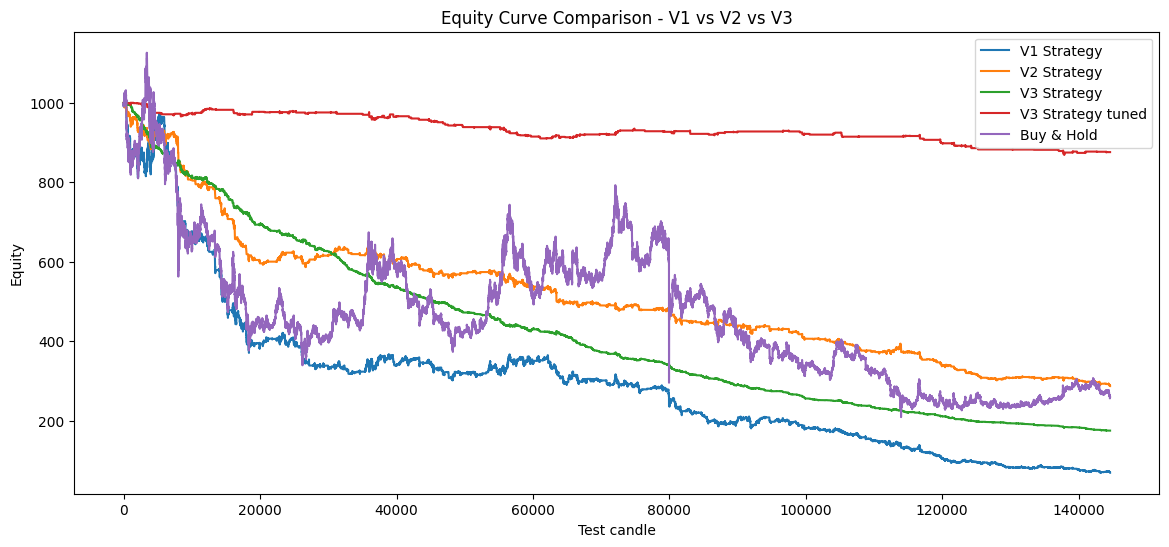

In [14]:
# ============================================================
# Equity curve comparison
# Se comparan visualmente las curvas de equity de V1, V2, V3, V3 tuned y Buy & Hold.
# La finalidad es estudiar no solo el capital final, sino la forma temporal del deterioro o recuperación del capital.
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(v1_results["equity_v1"].values, label="V1 Strategy")
plt.plot(v2_results["equity_v2"].values, label="V2 Strategy")
plt.plot(v3_results["equity_v3"].values, label="V3 Strategy")
plt.plot(best_v3_results["equity_v3"].values, label="V3 Strategy tuned")
plt.plot(buy_hold_equity.reset_index(drop=True).values, label="Buy & Hold")

plt.legend()
plt.title("Equity Curve Comparison - V1 vs V2 vs V3")
plt.xlabel("Test candle")
plt.ylabel("Equity")
plt.show()


## Interpretación de la curva de equity

La curva de equity permite ver mejor la diferencia entre deterioro operativo y preservación de capital.

V1 muestra una caída muy severa, coherente con un sistema que sobreopera con exposición completa. V2 reduce la velocidad y profundidad del deterioro, lo que confirma que el suavizado de probabilidades, el ATR TP/SL y el position sizing limitado mejoran la robustez operativa. V3 base introduce actividad long y short, pero su curva sigue deteriorándose de forma relevante, señal de que la complejidad adicional no basta si la señal predictiva continúa siendo débil.

La variante V3 tuned presenta una curva mucho más estable. Sin embargo, esta estabilidad debe interpretarse con cautela: la mejora procede en gran parte de reducir exposición y operar menos, no necesariamente de capturar de forma consistente movimientos favorables del mercado. En otras palabras, el tuning evita muchas pérdidas, pero no demuestra todavía una capacidad clara para extraer rentabilidad activa.

La lectura más defendible es que V3 tuned mejora la preservación de capital frente a V3 base, V1 y Buy & Hold, pero lo hace mediante una estrategia muy selectiva. Esto es metodológicamente interesante porque demuestra el impacto del control operativo, aunque no valida todavía el modelo como motor de decisión suficientemente fuerte.


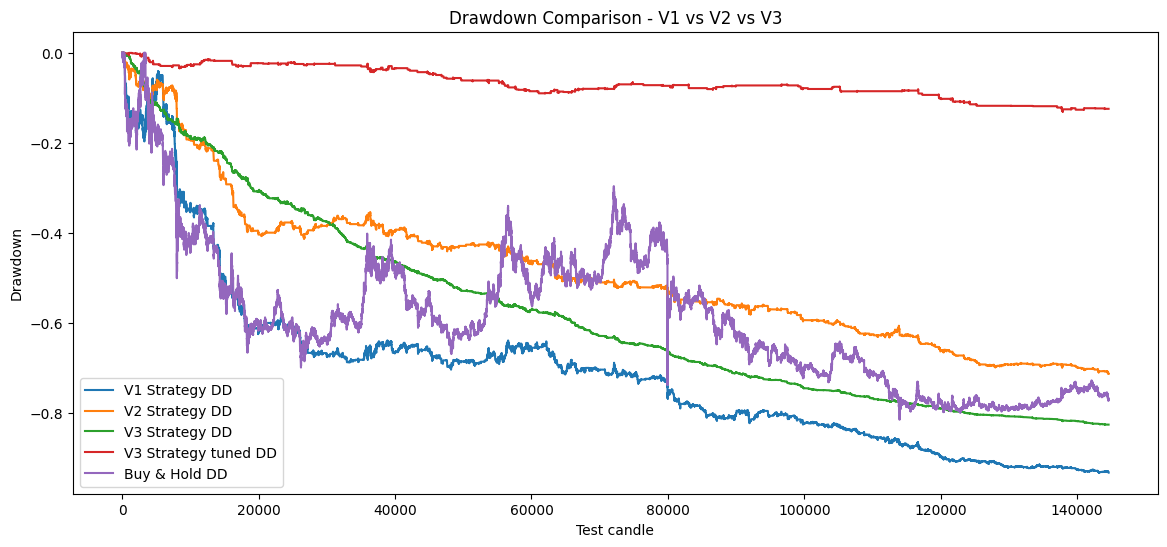

In [15]:
# ============================================================
# Drawdown comparison
# Se calculan y visualizan los drawdowns acumulados para comparar el riesgo temporal de V1, V2, V3, V3 tuned y Buy & Hold.
# ============================================================

v1_drawdown = compute_drawdown(v1_results["equity_v1"])
v2_drawdown = compute_drawdown(v2_results["equity_v2"])
v3_drawdown = compute_drawdown(v3_results["equity_v3"])
best_v3_drawdown = compute_drawdown(best_v3_results["equity_v3"])
buy_hold_drawdown = compute_drawdown(buy_hold_equity)

plt.figure(figsize=(14, 6))

plt.plot(v1_drawdown.values, label="V1 Strategy DD")
plt.plot(v2_drawdown.values, label="V2 Strategy DD")
plt.plot(v3_drawdown.values, label="V3 Strategy DD")
plt.plot(best_v3_drawdown.values, label="V3 Strategy tuned DD")
plt.plot(buy_hold_drawdown.values, label="Buy & Hold DD")

plt.legend()
plt.title("Drawdown Comparison - V1 vs V2 vs V3")
plt.xlabel("Test candle")
plt.ylabel("Drawdown")
plt.show()


## Interpretación del drawdown

El drawdown confirma que el principal avance de V3 tuned es defensivo.

V1 sufre un drawdown extremo, propio de una estrategia ingenua con sobreexposición y sobreoperación. V2 reduce significativamente ese deterioro, aunque sigue sometida a las limitaciones de una estrategia long-only en un entorno bajista. V3 base, pese a incorporar shorts y filtros de régimen, mantiene un drawdown elevado porque la mayor actividad y los costes explícitos penalizan mucho cuando las señales no tienen suficiente calidad.

La variante tuned reduce el drawdown de forma notable. Este resultado es relevante, pero debe interpretarse junto con la actividad operativa: una parte importante de la mejora procede de permanecer fuera del mercado durante más tiempo. El sistema no está resolviendo completamente el problema de predicción, sino evitando operar salvo cuando la configuración de thresholds exige más convicción.

Por tanto, el drawdown apoya una conclusión equilibrada: V3 aporta herramientas útiles de control de riesgo, pero la robustez conseguida depende mucho de restringir la exposición. La siguiente mejora lógica no debería consistir solo en seguir ajustando thresholds, sino en reforzar la señal predictiva y evaluar si el modelo puede generar mejores entradas sin necesitar tanta protección externa.


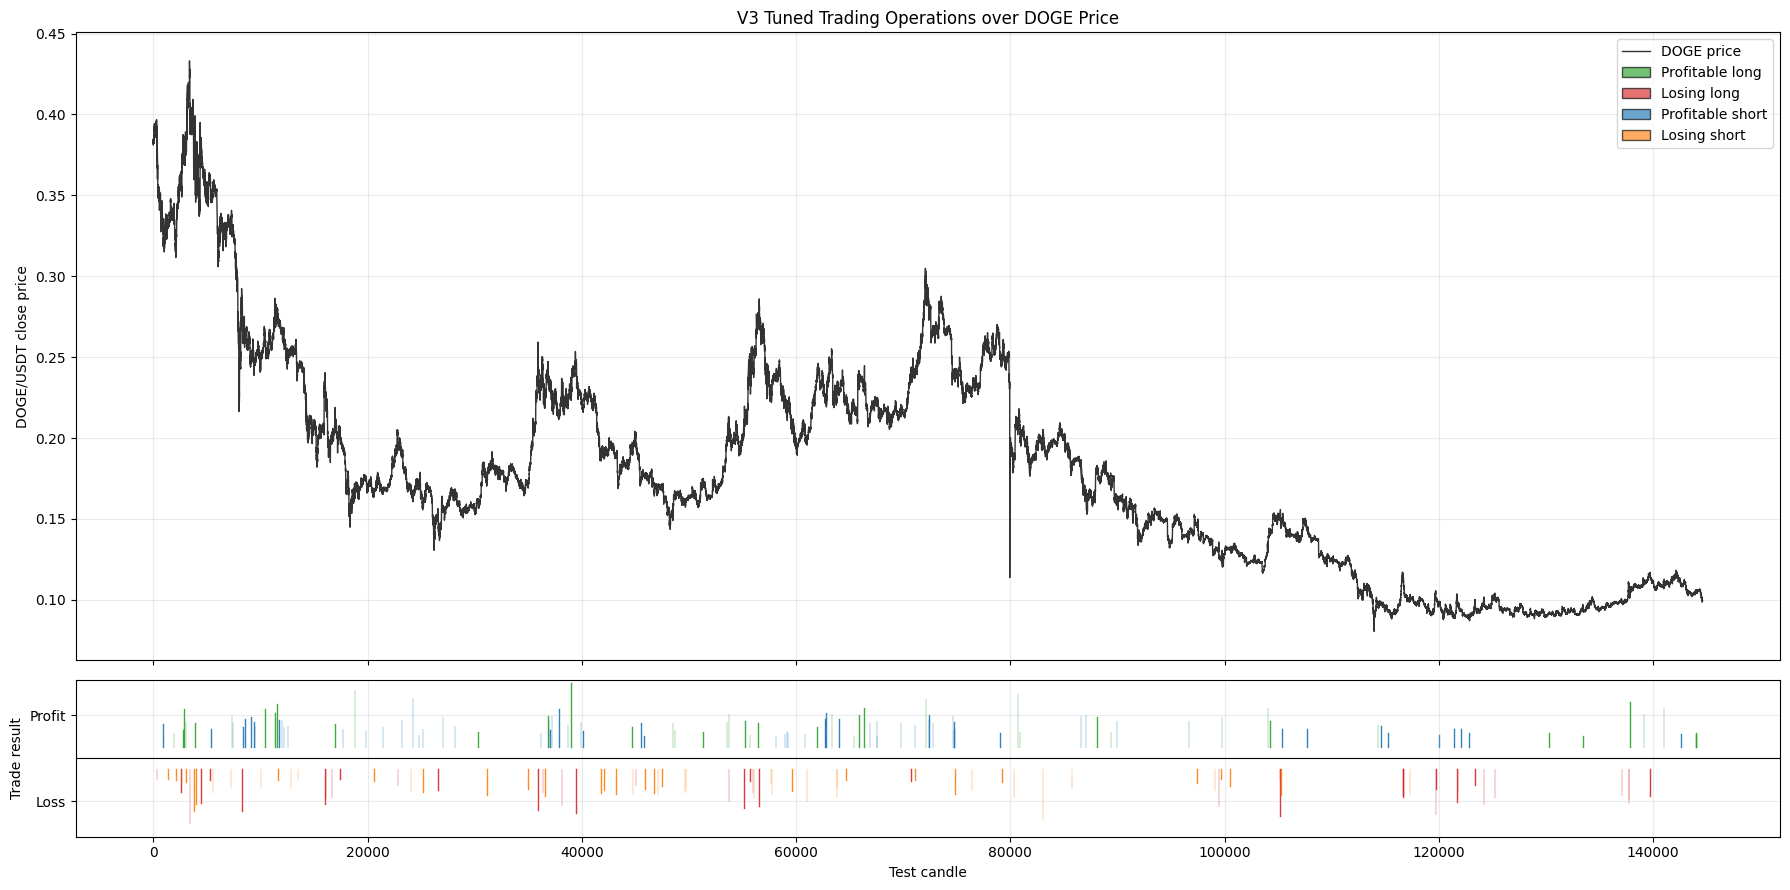

,side,entry_idx,exit_idx,entry_price,exit_price,pnl_pct,duration_bars,result
0,LONG,347,353,0.38450,0.38448,-0.005202,6,LOSS
1,SHORT,968,979,0.33097,0.32866,0.702854,11,PROFIT
2,SHORT,1430,1434,0.33340,0.33350,-0.029985,4,LOSS
3,LONG,1954,1956,0.33517,0.33588,0.211833,2,PROFIT
4,SHORT,2184,2187,0.33360,0.33386,-0.077877,3,LOSS
...,...,...,...,...,...,...,...,...
191,LONG,139760,139762,0.11385,0.11276,-0.957400,2,LOSS
192,LONG,140999,141016,0.10765,0.10934,1.569902,17,PROFIT
193,SHORT,142653,142657,0.10929,0.10915,0.128264,4,PROFIT
194,LONG,144032,144033,0.10512,0.10532,0.190259,1,PROFIT


In [22]:
# ============================================================
# Trading operations timeline
# Se visualizan las operaciones completas de V3 ajustada en una banda separada bajo el precio.
# Cada bloque representa una operación desde entrada hasta salida; el color indica tipo y resultado, y la altura representa el PnL relativo.
# ============================================================

import matplotlib.patches as patches

plot_df = bt_comparison.copy().reset_index(drop=True)
actions_df = best_v3_results.copy().reset_index(drop=True)

trade_rows = []
current_trade = None

for i, row in actions_df.iterrows():
    action = row["action_v3"]
    price_i = float(plot_df.loc[i, "close"])

    if action in ["OPEN_LONG", "OPEN_SHORT"]:
        current_trade = {
            "side": "LONG" if action == "OPEN_LONG" else "SHORT",
            "entry_idx": i,
            "entry_price": price_i
        }

    elif action in ["CLOSE_LONG", "CLOSE_SHORT"] and current_trade is not None:
        exit_idx = i
        exit_price = price_i

        if current_trade["side"] == "LONG":
            pnl_pct = (exit_price / current_trade["entry_price"] - 1) * 100
        else:
            pnl_pct = (current_trade["entry_price"] / exit_price - 1) * 100

        trade_rows.append({
            "side": current_trade["side"],
            "entry_idx": current_trade["entry_idx"],
            "exit_idx": exit_idx,
            "entry_price": current_trade["entry_price"],
            "exit_price": exit_price,
            "pnl_pct": pnl_pct,
            "duration_bars": exit_idx - current_trade["entry_idx"],
            "result": "PROFIT" if pnl_pct >= 0 else "LOSS"
        })

        current_trade = None

trades_df = pd.DataFrame(trade_rows)

price = plot_df["close"].astype(float).reset_index(drop=True)
x = np.arange(len(price))

fig, (ax_price, ax_trades) = plt.subplots(
    2,
    1,
    figsize=(18, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

ax_price.plot(
    x,
    price,
    color="black",
    linewidth=1.0,
    alpha=0.8,
    label="DOGE price"
)

ax_price.set_title("V3 Tuned Trading Operations over DOGE Price")
ax_price.set_ylabel("DOGE/USDT close price")
ax_price.grid(alpha=0.25)
ax_price.legend(loc="best")

if not trades_df.empty:
    max_abs_pnl = max(trades_df["pnl_pct"].abs().max(), 1e-9)

    for _, trade in trades_df.iterrows():
        entry_idx = int(trade["entry_idx"])
        exit_idx = int(trade["exit_idx"])
        actual_width = max(exit_idx - entry_idx, 1)
        visual_width = max(actual_width, 45)
        x_start = entry_idx - (visual_width - actual_width) / 2

        pnl_scaled = abs(trade["pnl_pct"]) / max_abs_pnl
        height = 0.15 + pnl_scaled * 0.75

        if trade["side"] == "LONG" and trade["result"] == "PROFIT":
            y_base = 0.15
            color = "tab:green"
            label = "Profitable long"
        elif trade["side"] == "LONG" and trade["result"] == "LOSS":
            y_base = -0.15 - height
            color = "tab:red"
            label = "Losing long"
        elif trade["side"] == "SHORT" and trade["result"] == "PROFIT":
            y_base = 0.15
            color = "tab:blue"
            label = "Profitable short"
        else:
            y_base = -0.15 - height
            color = "tab:orange"
            label = "Losing short"

        hatch = "" if trade["side"] == "LONG" else "//"

        rect = patches.Rectangle(
            (x_start, y_base),
            visual_width,
            height,
            linewidth=0.3,
            edgecolor=color,
            facecolor=color,
            alpha=0.85,
            hatch=hatch
        )

        ax_trades.add_patch(rect)

ax_trades.axhline(0, color="black", linewidth=0.8)
ax_trades.set_ylim(-1.1, 1.1)
ax_trades.set_ylabel("Trade result")
ax_trades.set_xlabel("Test candle")
ax_trades.set_yticks([-0.6, 0.6])
ax_trades.set_yticklabels(["Loss", "Profit"])
ax_trades.grid(alpha=0.25)

legend_handles = [
    patches.Patch(facecolor="tab:green", edgecolor="black", alpha=0.65, label="Profitable long"),
    patches.Patch(facecolor="tab:red", edgecolor="black", alpha=0.65, label="Losing long"),
    patches.Patch(facecolor="tab:blue", edgecolor="black", alpha=0.65, label="Profitable short"),
    patches.Patch(facecolor="tab:orange", edgecolor="black", alpha=0.65, label="Losing short"),
]

ax_price.legend(
    handles=[ax_price.get_legend_handles_labels()[0][0]] + legend_handles,
    loc="upper right"
)

plt.tight_layout()
plt.show()

display(trades_df)

## Interpretación de operaciones sobre el precio

La visualización de operaciones sobre el precio muestra que V3 ya no es un sistema prácticamente inactivo. La estrategia abre tanto posiciones long como short, lo que permite analizar el comportamiento de la lógica avanzada en distintos tramos de mercado.

Este punto es importante porque la primera aproximación de V3 tendía a quedarse casi siempre en cash. Esa configuración podía producir una equity aparentemente estable, pero aportaba poco valor analítico: una estrategia que apenas opera no permite evaluar si los shorts, los filtros de régimen o el position sizing están funcionando. En esta versión, la actividad es suficiente para estudiar aciertos, errores y sensibilidad del sistema.

Aun así, la distribución de operaciones también refleja la debilidad del modelo base. La estrategia necesita thresholds y filtros para evitar que la señal genere demasiadas entradas de baja calidad. Los shorts aportan una dimensión nueva y hacen que V3 sea conceptualmente más adecuado para un mercado bajista, pero todavía no demuestran una explotación sólida del régimen descendente.

La conclusión operativa es que V3 mejora como laboratorio de backtesting: permite observar cuándo entra, cuándo sale y cómo se comporta bajo costes más realistas. Sin embargo, la calidad de las entradas sigue dependiendo de una señal ML limitada, por lo que los resultados deben entenderse como una evolución metodológica, no como validación de una estrategia rentable.


In [17]:
# ============================================================
# Save V3 results
# Se guardan por separado los resultados de V3 base y V3 tuned para mantener trazabilidad entre la estrategia activa inicial y la variante seleccionada por threshold tuning.
# ============================================================

v3_base_metrics = comparative_metrics_df.loc["V3 Strategy"].to_dict()
v3_tuned_metrics = compute_strategy_metrics(
    best_v3_results["equity_v3"],
    best_v3_results["action_v3"],
)

v3_base_activity = {
    "total_actions": int((v3_results["action_v3"] != "HOLD").sum()),
    "hold_ratio": float((v3_results["action_v3"] == "HOLD").mean()),
    "long_entries": int((v3_results["action_v3"] == "OPEN_LONG").sum()),
    "short_entries": int((v3_results["action_v3"] == "OPEN_SHORT").sum()),
    "long_exits": int((v3_results["action_v3"] == "CLOSE_LONG").sum()),
    "short_exits": int((v3_results["action_v3"] == "CLOSE_SHORT").sum()),
}

v3_tuned_activity = {
    "total_actions": int((best_v3_results["action_v3"] != "HOLD").sum()),
    "hold_ratio": float((best_v3_results["action_v3"] == "HOLD").mean()),
    "long_entries": int((best_v3_results["action_v3"] == "OPEN_LONG").sum()),
    "short_entries": int((best_v3_results["action_v3"] == "OPEN_SHORT").sum()),
    "long_exits": int((best_v3_results["action_v3"] == "CLOSE_LONG").sum()),
    "short_exits": int((best_v3_results["action_v3"] == "CLOSE_SHORT").sum()),
}

comparison_df = pd.DataFrame({
    "v1_equity": v1_results["equity_v1"].reset_index(drop=True),
    "v2_equity": v2_results["equity_v2"].reset_index(drop=True),
    "v3_base_equity": v3_results["equity_v3"].reset_index(drop=True),
    "v3_tuned_equity": best_v3_results["equity_v3"].reset_index(drop=True),
    "buy_hold_equity": buy_hold_equity.reset_index(drop=True),
    "v1_drawdown": compute_drawdown(v1_results["equity_v1"]).reset_index(drop=True),
    "v2_drawdown": compute_drawdown(v2_results["equity_v2"]).reset_index(drop=True),
    "v3_base_drawdown": compute_drawdown(v3_results["equity_v3"]).reset_index(drop=True),
    "v3_tuned_drawdown": compute_drawdown(best_v3_results["equity_v3"]).reset_index(drop=True),
    "buy_hold_drawdown": compute_drawdown(buy_hold_equity).reset_index(drop=True),
})

results_summary = {
    "notebook": "07_backtesting_v3",
    "strategy": "Long and short supervised model with regime filters, slippage, fees, threshold tuning and dynamic position sizing",
    "initial_balance": INITIAL_BALANCE,

    "v3_base_final_balance": v3_base_metrics["final_balance"],
    "v3_base_return_pct": v3_base_metrics["total_return_%"],
    "v3_base_max_drawdown_pct": v3_base_metrics["max_drawdown_%"],
    "v3_base_sharpe_ratio": v3_base_metrics["sharpe_approx"],
    "v3_base_num_operations": v3_base_activity["total_actions"],
    "v3_base_hold_ratio": v3_base_activity["hold_ratio"],
    "v3_base_long_entries": v3_base_activity["long_entries"],
    "v3_base_short_entries": v3_base_activity["short_entries"],

    "v3_tuned_final_balance": v3_tuned_metrics["final_balance"],
    "v3_tuned_return_pct": v3_tuned_metrics["total_return_%"],
    "v3_tuned_max_drawdown_pct": v3_tuned_metrics["max_drawdown_%"],
    "v3_tuned_sharpe_ratio": v3_tuned_metrics["sharpe_approx"],
    "v3_tuned_num_operations": v3_tuned_activity["total_actions"],
    "v3_tuned_hold_ratio": v3_tuned_activity["hold_ratio"],
    "v3_tuned_long_entries": v3_tuned_activity["long_entries"],
    "v3_tuned_short_entries": v3_tuned_activity["short_entries"],

    "selected_variant": "V3 tuned",
    "selected_final_balance": v3_tuned_metrics["final_balance"],
    "selected_return_pct": v3_tuned_metrics["total_return_%"],
    "selected_max_drawdown_pct": v3_tuned_metrics["max_drawdown_%"],

    "buy_and_hold_final_balance": comparative_metrics_df.loc["Buy & Hold", "final_balance"],
    "buy_and_hold_return_pct": comparative_metrics_df.loc["Buy & Hold", "total_return_%"],
    "buy_and_hold_max_drawdown_pct": comparative_metrics_df.loc["Buy & Hold", "max_drawdown_%"],

    "v1_final_balance": comparative_metrics_df.loc["V1 Strategy", "final_balance"],
    "v1_return_pct": comparative_metrics_df.loc["V1 Strategy", "total_return_%"],
    "v1_max_drawdown_pct": comparative_metrics_df.loc["V1 Strategy", "max_drawdown_%"],

    "v2_final_balance": comparative_metrics_df.loc["V2 Strategy", "final_balance"],
    "v2_return_pct": comparative_metrics_df.loc["V2 Strategy", "total_return_%"],
    "v2_max_drawdown_pct": comparative_metrics_df.loc["V2 Strategy", "max_drawdown_%"],

    "best_long_threshold": BEST_LONG_THRESHOLD,
    "best_short_threshold": BEST_SHORT_THRESHOLD,
    "fees_applied": True,
    "fee_rate": FEE_RATE,
    "slippage_applied": True,
    "slippage_rate": SLIPPAGE_RATE,
    "position_sizing": "Dynamic bounded position sizing",
    "max_position_size": V3_MAX_POSITION_SIZE,
    "regime_filter_applied": True,
    "main_limitation": "V3 tuned improves preservation of capital mainly by reducing exposure, so the result should be interpreted as risk control rather than proof of a strong predictive edge"
}

results_summary_df = pd.DataFrame([results_summary])

v3_variant_summary_df = pd.DataFrame([
    {
        "variant": "V3 base",
        "final_balance": v3_base_metrics["final_balance"],
        "return_pct": v3_base_metrics["total_return_%"],
        "max_drawdown_pct": v3_base_metrics["max_drawdown_%"],
        "sharpe_ratio": v3_base_metrics["sharpe_approx"],
        **v3_base_activity,
    },
    {
        "variant": "V3 tuned",
        "final_balance": v3_tuned_metrics["final_balance"],
        "return_pct": v3_tuned_metrics["total_return_%"],
        "max_drawdown_pct": v3_tuned_metrics["max_drawdown_%"],
        "sharpe_ratio": v3_tuned_metrics["sharpe_approx"],
        **v3_tuned_activity,
    },
])

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_summary_df.to_csv(RESULTS_DIR / "07_backtesting_v3_summary.csv", index=False)
v3_variant_summary_df.to_csv(RESULTS_DIR / "07_backtesting_v3_variant_summary.csv", index=False)
comparative_metrics_df.to_csv(RESULTS_DIR / "07_backtesting_v3_comparison.csv", index=True)
tuning_df.to_csv(RESULTS_DIR / "07_backtesting_v3_threshold_tuning.csv", index=False)
comparison_df.to_csv(RESULTS_DIR / "07_backtesting_v3_equity_drawdown.csv", index=False)
trade_activity_summary.to_csv(RESULTS_DIR / "07_backtesting_v3_trade_activity.csv", index=False)
v3_results.to_csv(RESULTS_DIR / "07_backtesting_v3_base_backtest.csv", index=False)
best_v3_results.to_csv(RESULTS_DIR / "07_backtesting_v3_tuned_backtest.csv", index=False)

print("Saved V3 results to:", RESULTS_DIR)

display(results_summary_df)
display(v3_variant_summary_df)


Saved V3 results to: ..\results


,notebook,strategy,initial_balance,v3_base_final_balance,v3_base_return_pct,v3_base_max_drawdown_pct,v3_base_sharpe_ratio,v3_base_num_operations,v3_base_hold_ratio,v3_base_long_entries,...,best_long_threshold,best_short_threshold,fees_applied,fee_rate,slippage_applied,slippage_rate,position_sizing,max_position_size,regime_filter_applied,main_limitation
0,07_backtesting_v3,Long and short supervised model with regime fi...,1000,175.355423,-82.464458,-82.495168,-14.428618,4352,0.969907,469,...,0.58,0.42,True,0.001,True,0.0005,Dynamic bounded position sizing,0.5,True,V3 tuned improves preservation of capital main...


,variant,final_balance,return_pct,max_drawdown_pct,sharpe_ratio,total_actions,hold_ratio,long_entries,short_entries,long_exits,short_exits
0,V3 base,175.355423,-82.464458,-82.495168,-14.428618,4352,0.969907,469,1707,469,1707
1,V3 tuned,876.156393,-12.384361,-13.154542,-2.667567,392,0.997289,86,110,86,110


## Conclusión

Backtesting V3 cierra la progresión experimental iniciada con V1 y V2 añadiendo una capa operativa más realista y flexible. La estrategia incorpora filtros de régimen, posiciones long y short simuladas, slippage, fees explícitas, TP/SL dinámicos y position sizing dependiente de la confianza.

La comparación muestra una conclusión matizada. V3 base no mejora automáticamente a V2: aunque añade más elementos operativos, también incrementa la actividad y los costes, y sigue dependiendo de un modelo supervisado con capacidad predictiva limitada. Esto confirma una idea importante para el proyecto: en trading algorítmico, añadir complejidad no equivale necesariamente a mejorar el rendimiento.

El threshold tuning mejora mucho la preservación de capital, pero lo hace principalmente reduciendo la exposición al mercado. Esta es una lectura central del notebook: el tuning recurre parcialmente a la inacción para protegerse de un modelo todavía flojo. La mejora no debe interpretarse como prueba de una ventaja financiera robusta, sino como evidencia de que la gestión de riesgo y la selectividad pueden contener parte del deterioro.

Desde el punto de vista metodológico, V3 sí aporta valor al TFM. Permite comparar tres niveles de madurez del sistema:

- V1 demuestra que buenas métricas de clasificación no garantizan rentabilidad financiera
- V2 demuestra que mejoras operativas simples pueden reducir el daño y estabilizar la equity
- V3 demuestra que una simulación más realista permite controlar exposición, analizar shorts y estudiar sensibilidad de thresholds, aunque el edge predictivo siga siendo insuficiente

La conclusión final es que el sistema ha mejorado como framework de evaluación y control de riesgo, pero no todavía como estrategia rentable. El siguiente paso natural no es seguir endureciendo filtros hasta que el bot deje de operar, sino volver sobre el modelo: mejorar features, calibración de probabilidades, detección de régimen y validación temporal para comprobar si puede generarse una señal más informativa.
